# Poking at `engine.py`

A visual test bench for the Stockfish wrapper. Every claim the module's
docstrings make gets exercised here against a real engine, with the board
drawn so you can see what the numbers are talking about.

Sections:

1. [Setup and helpers](#setup)
2. [`best` and `top_moves`](#best)
3. [`cp_loss` across every legal move](#cploss)
4. [Whose point of view?](#pov)
5. [Terminal positions](#terminal)
6. [The mate score and the cap](#mate)
7. [The cache](#cache)
8. [Is it actually reproducible?](#determinism)

<a id="setup"></a>
## 1. Setup and helpers

`show()` renders one or more boards side by side with optional arrows. Green
arrows are the engine's choice, red are blunders, grey are alternatives.

In [57]:
import chess
import chess.svg
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from engine import CP_LOSS_CAP, MATE_SCORE, Engine

GREEN, RED, GREY = "#15781B", "#B01B1B", "#5A5A5A"


def arrow(move, color=GREEN):
    return chess.svg.Arrow(move.from_square, move.to_square, color=color)


def show(*panels, size=300):
    """show((board, caption, arrows), ...) -- boards laid out in a row."""
    html = []
    for panel in panels:
        board, caption, arrows = (panel + ((),))[:3] if len(panel) < 3 else panel
        svg = chess.svg.board(
            board, size=size, arrows=list(arrows), coordinates=True
        )
        html.append(
            f'<div style="text-align:center;font-family:sans-serif;'
            f'font-size:13px;margin:0 10px">{svg}<div style="margin-top:6px">'
            f"{caption}</div></div>"
        )
    display(HTML(f'<div style="display:flex;flex-wrap:wrap">{"".join(html)}</div>'))

In [58]:
eng = Engine(depth=12)
print("depth:", eng.limit.depth, "| MATE_SCORE:", MATE_SCORE, "| cap:", CP_LOSS_CAP)

depth: 12 | MATE_SCORE: 10000 | cap: 1000


<a id="best"></a>
## 2. `best` and `top_moves`

An Italian Game position, five moves in. `top_moves(board, k)` runs Stockfish
in multi-PV mode and returns the k best lines, best first.

In [59]:
ITALIAN = "r1bqk2r/pppp1ppp/2n2n2/2b1p3/2B1P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 6 5"
board = chess.Board(ITALIAN)

top3 = eng.top_moves(board, k=3)
for rank, (move, cp) in enumerate(top3, 1):
    print(f"{rank}. {board.san(move):6} {cp:+5} cp")

show((
    board,
    "White to move &mdash; top 3 engine choices",
    [arrow(m, GREEN if i == 0 else GREY) for i, (m, _) in enumerate(top3)],
), size=360)

1. d3       -11 cp
2. Nc3      -12 cp
3. Qe2      -55 cp


In [60]:
move, cp = eng.best(board)
print(f"best():      {board.san(move):5} {cp:+5} cp")
print(f"top_moves[0]: {board.san(top3[0][0]):4} {top3[0][1]:+5} cp")
print(f"\nsame move:  {move == top3[0][0]}")
print(f"same score: {cp == top3[0][1]}   <- not guaranteed")

best():      d3      -13 cp
top_moves[0]: d3     -11 cp

same move:  True
same score: False   <- not guaranteed


<a id="cploss"></a>
## 3. `cp_loss` across every legal move

This is the reward signal. Score all 33 legal moves and sort them: the shape of
this distribution is what the model is being trained to climb.

In [61]:
losses = sorted(
    ((eng.cp_loss(board, m), board.san(m)) for m in board.legal_moves)
)
under_pawn = sum(cp < 100 for cp, _ in losses)

print(f"{len(losses)} legal moves, {losses[0][0]} to {losses[-1][0]} cp lost")
print(f"within a pawn of best: {under_pawn}/{len(losses)}"
      f" ({under_pawn / len(losses):.0%})")

33 legal moves, 0 to 500 cp lost
within a pawn of best: 6/33 (18%)


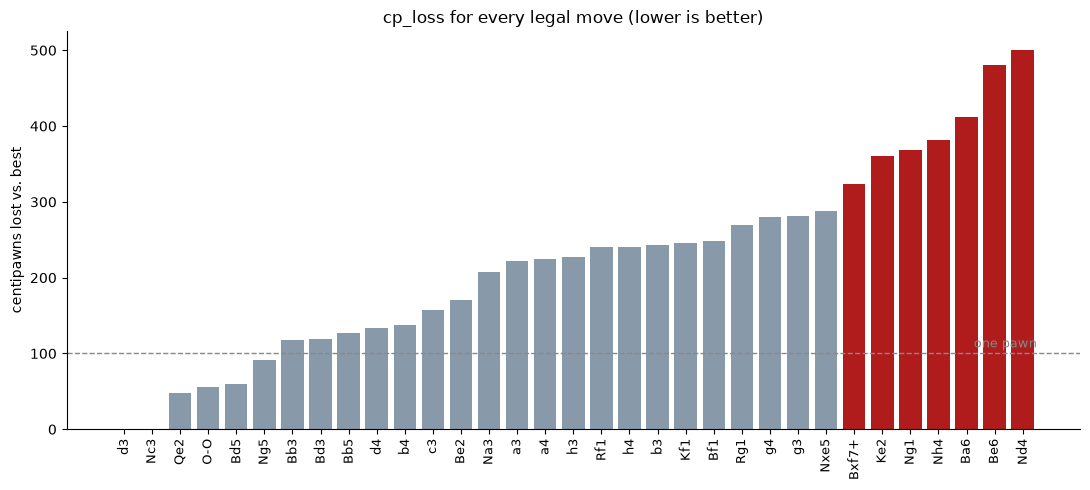

In [62]:
cps = [cp for cp, _ in losses]
sans = [san for _, san in losses]

fig, ax = plt.subplots(figsize=(11, 5))
colors = [GREEN if c <= 10 else RED if c >= 300 else "#8899AA" for c in cps]
ax.bar(range(len(cps)), cps, color=colors)
ax.set_xticks(range(len(cps)))
ax.set_xticklabels(sans, rotation=90, fontsize=9)
ax.set_ylabel("centipawns lost vs. best")
ax.set_title("cp_loss for every legal move (lower is better)")
ax.axhline(100, color="#888", ls="--", lw=1)
ax.text(len(cps) - 0.5, 108, "one pawn", ha="right", fontsize=9, color="#888")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Only a handful of the legal moves land within a pawn of best, and the
distribution climbs steadily rather than splitting into "good" and "bad" piles.
That is useful for training: a model that is roughly reasonable gets a
meaningfully better reward than one picking at random, instead of both landing
in the same bucket.

The two ends of the distribution, on the board:

In [63]:
best_san, worst_san = sans[0], sans[-1]
best_mv, worst_mv = board.parse_san(best_san), board.parse_san(worst_san)

show(
    (board, f"best: <b>{best_san}</b> &mdash; 0 cp lost", [arrow(best_mv, GREEN)]),
    (board, f"worst: <b>{worst_san}</b> &mdash; {cps[-1]} cp lost",
     [arrow(worst_mv, RED)]),
)

<a id="pov"></a>
## 4. Whose point of view?

The module header promises every score comes from one explicit POV. The test:
take a position where Black is to move and blundering, and check that
`cp_loss` still comes back positive. If the `.pov(mover)` call at
[engine.py:90](engine.py) were dropped, hanging a queen would score as a
*reward* rather than a loss.

In [64]:
# A quiet position where Black is to move, has one clear best move, and has
# several ways to hang the queen.
BLACK_TO_MOVE = "rnbqkbnr/ppp2ppp/8/3pp3/4P3/5N2/PPPP1PPP/RNBQKB1R b KQkq - 0 3"
bb = chess.Board(BLACK_TO_MOVE)
print("turn:", "Black" if bb.turn == chess.BLACK else "White")

bmove, bcp = eng.best(bb)
print(f"best for Black: {bb.san(bmove)}  ({bcp:+} cp, from Black's POV)")

sample = sorted(((eng.cp_loss(bb, m), bb.san(m)) for m in bb.legal_moves))
print("\nall losses >= 0:", all(cp >= 0 for cp, _ in sample))
print("cheapest:", sample[:3])
print("priciest:", sample[-3:])

turn: Black
best for Black: dxe4  (+119 cp, from Black's POV)

all losses >= 0: True
cheapest: [(0, 'dxe4'), (82, 'Nf6'), (131, 'Nc6')]
priciest: [(493, 'Ba3'), (742, 'Qh4'), (798, 'Qg5')]


In [65]:
show(
    (bb, f"Black's best: <b>{sample[0][1]}</b> ({sample[0][0]} cp lost)",
     [arrow(bb.parse_san(sample[0][1]), GREEN)]),
    (bb, f"Black's worst: <b>{sample[-1][1]}</b> ({sample[-1][0]} cp lost)",
     [arrow(bb.parse_san(sample[-1][1]), RED)]),
)

Positive losses for a Black mover, with the sign pointing the same direction as
it did for White. The POV pinning works &mdash; drop the `.pov(mover)` and the
ordering inverts, so hanging the queen with `Qh4` becomes the cheapest move on
the list rather than the priciest.

The best move scores exactly `0`, as it should. That is not free: it holds only
because `analyse` now clears the transposition table on every call, so the
cached `best()` score and the fresh post-move score are drawn from the same
state. Section 8 is where that fix comes from.

<a id="terminal"></a>
## 5. Terminal positions

The comment at [engine.py:81-83](engine.py) says asking Stockfish to analyse a
finished position can return garbage or kill the process, so `cp_loss` handles
checkmate, stalemate and insufficient material directly. All three branches:

In [66]:
MATE_IN_1 = "r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4"
mb = chess.Board(MATE_IN_1)
mate_mv = mb.parse_san("Qxf7#")
alt_mv = mb.parse_san("Qxe5+")

print("Qxf7# cp_loss:", eng.cp_loss(mb, mate_mv), " <- the mating move costs nothing")
print("Qxe5+ cp_loss:", eng.cp_loss(mb, alt_mv), " <- capped; declining mate is very bad , also hangs queen lol")

show((
    mb,
    "Scholar's mate: <b>Qxf7#</b> vs <b>Qxe5+</b>",
    [arrow(mate_mv, GREEN), arrow(alt_mv, RED)],
), size=360)

Qxf7# cp_loss: 0  <- the mating move costs nothing
Qxe5+ cp_loss: 1000  <- capped; declining mate is very bad , also hangs queen lol


In [67]:
STALEMATE = "7k/8/8/8/8/8/5Q2/7K w - - 0 1"
sb = chess.Board(STALEMATE)
stale_mv, good_mv = sb.parse_san("Qf7"), sb.parse_san("Qa7")

print("Qf7 (stalemate!) cp_loss:", eng.cp_loss(sb, stale_mv))
print("Qa7 (keeps winning) cp_loss:", eng.cp_loss(sb, good_mv))

after = sb.copy()
after.push(stale_mv)
show(
    (sb, "<b>Qf7</b> throws away the win &mdash; stalemate", [arrow(stale_mv, RED)]),
    (after, f"stalemate: {after.is_stalemate()}, Black has "
            f"{after.legal_moves.count()} legal moves"),
)

Qf7 (stalemate!) cp_loss: 561
Qa7 (keeps winning) cp_loss: 0


In [68]:
INSUFFICIENT = "8/8/8/4k3/8/8/4n3/4K3 w - - 0 1"
ib = chess.Board(INSUFFICIENT)
cap_mv = ib.parse_san("Kxe2")

after = ib.copy()
after.push(cap_mv)
print("Kxe2 cp_loss:", eng.cp_loss(ib, cap_mv))
print("insufficient material after capture:", after.is_insufficient_material())

show(
    (ib, "<b>Kxe2</b> &mdash; capture into a dead draw", [arrow(cap_mv, GREEN)]),
    (after, "K vs K: scored 0, not analysed"),
)

Kxe2 cp_loss: 0
insufficient material after capture: True


A near-zero loss, correctly: the position was already drawn, so trading into a
bare-kings draw gives up nothing. The branch matters less for the *value* here
than for not handing Stockfish a position it can't evaluate.

In [69]:
# cp_loss must leave the caller's board untouched -- it pushes and pops.
probe = chess.Board(ITALIAN)
before_fen = probe.fen()
for m in list(probe.legal_moves)[:5]:
    eng.cp_loss(probe, m)
print("board unmodified:", probe.fen() == before_fen)

board unmodified: True


In [72]:
import time

fresh = Engine(depth=12)
probe = chess.Board(ITALIAN)

t0 = time.perf_counter(); fresh.best(probe); cold = time.perf_counter() - t0
t0 = time.perf_counter()
for _ in range(64):
    fresh.best(probe)
warm = time.perf_counter() - t0

print(f"cold call:        {cold * 1000:8.2f} ms")
print(f"64 cached calls:  {warm * 1000:8.2f} ms")
print(f"speedup per call: {cold / (warm / 64):8.0f}x")
print("cache entries:", len(fresh._best_cache))
fresh.close()

cold call:           55.03 ms
64 cached calls:      1.73 ms
speedup per call:     2039x
cache entries: 1
